# 06 - Homography

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Homography Basics

### What is Homography? 

**Homography** is a mapping that relates two different images that lie within the same 3D scene. 

Essentially, it will map the points on one image to points on the other image, creating a single merged image. This is the same idea behind creating panorama images. 

You can see this full process play out in the sample image below: 

![](ref_imgs/homography_ex.png)

#### The Key Assumption: 4 Overlapping Points

The image above shows us something interesting: it maps 4 points on each of the images to form the stitched image. 

This is actually a requirement of the homography - we must have overlap between the images such that we can map 4 points, with each point on the same object within the different images (except at a different perspective/position). Put in a more technical way, the 2D images must lie somewhere along the same 3D plane. 

It is for the same reason that within our limelight setup, we have to ensure the cameras line up in such a way that they have an overlapping field of view.

#### Step 1: Estimating Homography

How do we calculate the transformation? Well, we know that the mapping occurs for the same objects, so the transformation has to occur with coordinates that correspond to the given object in the different images. Don't worry if you are not super familiar with linear algebra, I am simply showing you this so you understand the fundamental concept of how we can encode a transformation into numbers.

We write out the relationship of an object's position from image 1 to image 2 as the following: 

$$
\begin{bmatrix}
x' \\
y' \\
1
\end{bmatrix}
=
H
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix}
$$ 

Where $H$ is the homography matrix, which is: 

$$
H =
\begin{bmatrix}
h_{11} & h_{12} & h_{13} \\
h_{21} & h_{22} & h_{23} \\
h_{31} & h_{32} & h_{33}
\end{bmatrix}
$$

So our homography equation expands out to: 

$$
\begin{bmatrix}
x' \\
y' \\
1
\end{bmatrix}
=
\begin{bmatrix}
h_{11} & h_{12} & h_{13} \\
h_{21} & h_{22} & h_{23} \\
h_{31} & h_{32} & h_{33}
\end{bmatrix}
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix}
$$

Each of those $h$ values corresponds to a different effect on the image - some control perspective, some rotation, etc. 

Since $H$ is only defined up to an overall scale (multiplying every entry by the same constant gives the same mapping), we can fix $h_{33} = 1$, leaving 8 unknown values ($h_{11}, h_{12}, h_{13}, h_{21}, h_{22}, h_{23}, h_{31}, h_{32}$) to solve for. Each pair of corresponding points $(x, y) \to (x', y')$ gives us 2 equations (one for $x'$, one for $y'$), so we need 4 point correspondences to get 8 equations - just enough to solve for our 8 unknowns.

It is *not* important to memorize what these do! Simply understand that by having overlap between images, there is a way for us to stitch images together! 

### Homography in Action

Let's actually compute and apply a homography. We'll pick 4 points on our familiar ball image outlining a quadrilateral on the floor, and 4 destination points forming a proper rectangle - the same idea as "straightening out" a shallow-angle floor view into a bird's-eye view.

Homography matrix:
[[ 7.61904762e-01  5.07936508e-01 -2.66666667e+02]
 [-4.13406683e-16  4.00000000e+00 -6.00000000e+02]
 [-2.70682947e-19  2.22222222e-03  1.00000000e+00]]


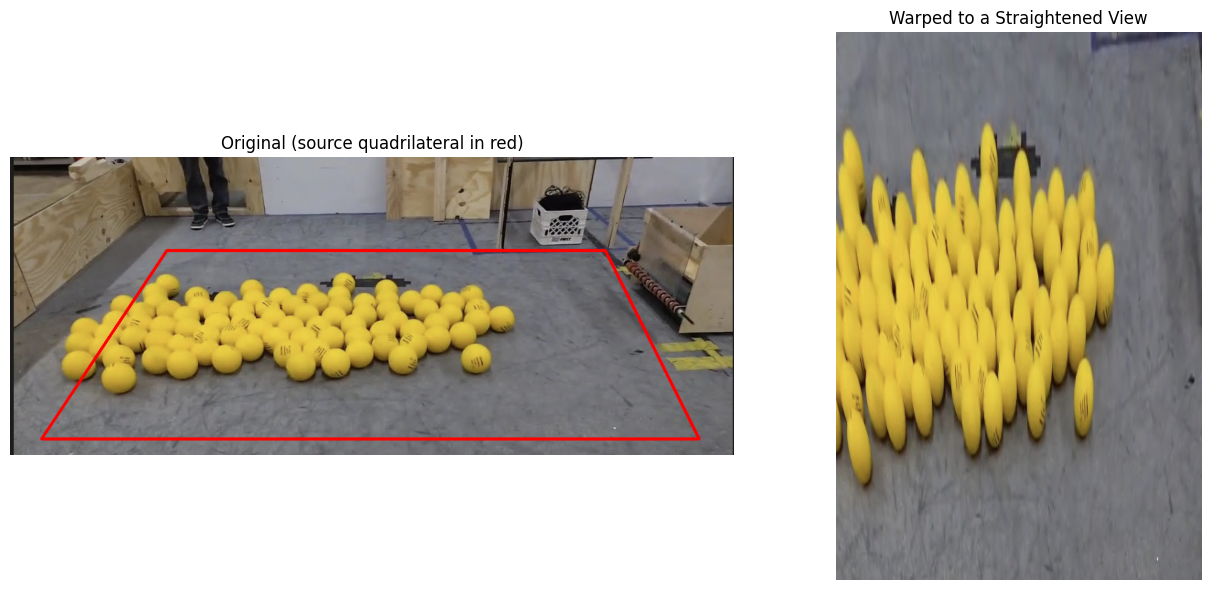

In [2]:
img_bgr = cv2.imread('./ref_imgs/balls_on_field.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 4 points roughly outlining a quadrilateral on the floor (following the perspective)
src_pts = np.float32([
    [250, 150],   # far-left
    [950, 150],   # far-right
    [1100, 450],  # near-right
    [50, 450]     # near-left
])

# where we want that quadrilateral to land: a straightened rectangle
dst_w, dst_h = 400, 600
dst_pts = np.float32([[0, 0], [dst_w, 0], [dst_w, dst_h], [0, dst_h]])

H = cv2.getPerspectiveTransform(src_pts, dst_pts)
print("Homography matrix:")
print(H)

warped = cv2.warpPerspective(img_rgb, H, (dst_w, dst_h))

# draw the source quadrilateral on the original for reference
img_with_quad = img_rgb.copy()
cv2.polylines(img_with_quad, [src_pts.astype(int)], isClosed=True, color=(255, 0, 0), thickness=4)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

ax[0].imshow(img_with_quad)
ax[0].set_title("Original (source quadrilateral in red)")
ax[0].axis("off")

ax[1].imshow(warped)
ax[1].set_title("Warped to a Straightened View")
ax[1].axis("off")

plt.tight_layout()
plt.show()

Notice the balls look stretched and elongated in the warped result, rather than perfectly circular. That's not a bug - it's because our 4 source points were a rough guess, not a precisely measured rectangle in the real world. Homography assumes those 4 points correspond to an *actual* rectangle (or whatever shape you specify) in 3D. Getting a clean, undistorted result in practice requires carefully measuring or calibrating those correspondences, which is exactly the kind of setup work that goes into field-relative vision pipelines.

### Why does it matter for Robotics? 

Homography in and of itself is not as crucial for our AprilTag or object detection with 2+ Limelights, because we are dealing with 3D objects and need to map 3D poses, in what is called **3D Pose Estimation**. 

We will be discussing how to perform this pose estimation in our Perception unit. Now that you understand homography, we will be able to expand this logic out from dealing with 2D images to dealing with 3D objects! 

## Try It Yourself

Using `cv2.getPerspectiveTransform`, do the reverse of the demo above: create a small synthetic image (a black background with a white square drawn on it, like the synthetic images from notebook 01), pick 4 source points (the square's corners) and 4 destination points forming a "stretched" quadrilateral. Compute `H`, then use `cv2.warpPerspective` to actually apply it and display the result. Does the warped image match what you'd expect from your chosen destination points?

In [3]:
# TODO: create a small synthetic image (e.g., black background with a white square), like in notebook 01
# TODO: define 4 source points (corners of the square) and 4 destination points (a stretched quadrilateral)
# TODO: compute H with cv2.getPerspectiveTransform, apply it with cv2.warpPerspective, and display the result

## Resources

- [OpenCV: Feature Matching + Homography to Find Objects](https://docs.opencv.org/4.x/d1/de0/tutorial_py_feature_homography.html) - a full tutorial on estimating and using a homography matrix.
- [OpenCV: `getPerspectiveTransform` documentation](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html) - the function used in the exercise above, along with `warpPerspective`.
- [Szeliski, R. *Computer Vision: Algorithms and Applications*, Chapter 2 & 11](https://szeliski.org/Book/) - covers homographies and image stitching/panoramas in depth.